# Cluster Visualization & Dimensionality Reduction (PCA)

## Executive Overview
In this final clustering notebook, we apply **Principal Component Analysis (PCA)** to project our high-dimensional behavioral feature space ($X \in \mathbb{R}^{13}$) into 2D components.

### Objectives
1. **Dimensionality Reduction:** Compress behavioral variance into orthogonal components ($PC_1, PC_2$).
2. **Boundary Inspection:** Evaluate the spatial separation of the 4 K-Means behavioral clusters in reduced dimensions.
3. **Feature Loadings Analysis:** Identify which original behavioral attributes drive the primary axes of variance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="white")

# Cargar el CSV procesado QUE SÍ TIENE la columna 'Cluster'
X_scaled = pd.read_csv('../data/processed/X_scaled_with_clusters.csv')

# Separar la columna 'Cluster' de la matriz de features
cluster_labels = X_scaled['Cluster']
X_features = X_scaled.drop(columns=['Cluster'])

print(f"Features loaded successfully: {X_features.shape}")
print(f"Cluster labels shape: {cluster_labels.shape}")

Features loaded successfully: (2111, 17)
Cluster labels shape: (2111,)


## 1. PCA Transformation & Explained Variance

We fit a 2-component PCA model to capture maximum feature variance while enabling 2D visual mapping.

In [2]:
# Fit PCA with 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_features)

# Create DataFrame for PCA results
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels

# Print Explained Variance Ratio
var_pc1, var_pc2 = pca.explained_variance_ratio_ * 100
print(f"Explained Variance Ratio:")
print(f" - PC1: {var_pc1:.2f}%")
print(f" - PC2: {var_pc2:.2f}%")
print(f" - Total Retained Variance (2D): {var_pc1 + var_pc2:.2f}%")

Explained Variance Ratio:
 - PC1: 19.11%
 - PC2: 16.49%
 - Total Retained Variance (2D): 35.60%


## 2. Visualizing Clusters in Principal Component Space

We project the 13-dimensional behavioral features into a 2D space using the first two Principal Components ($PC_1$ and $PC_2$) to inspect cluster boundaries.

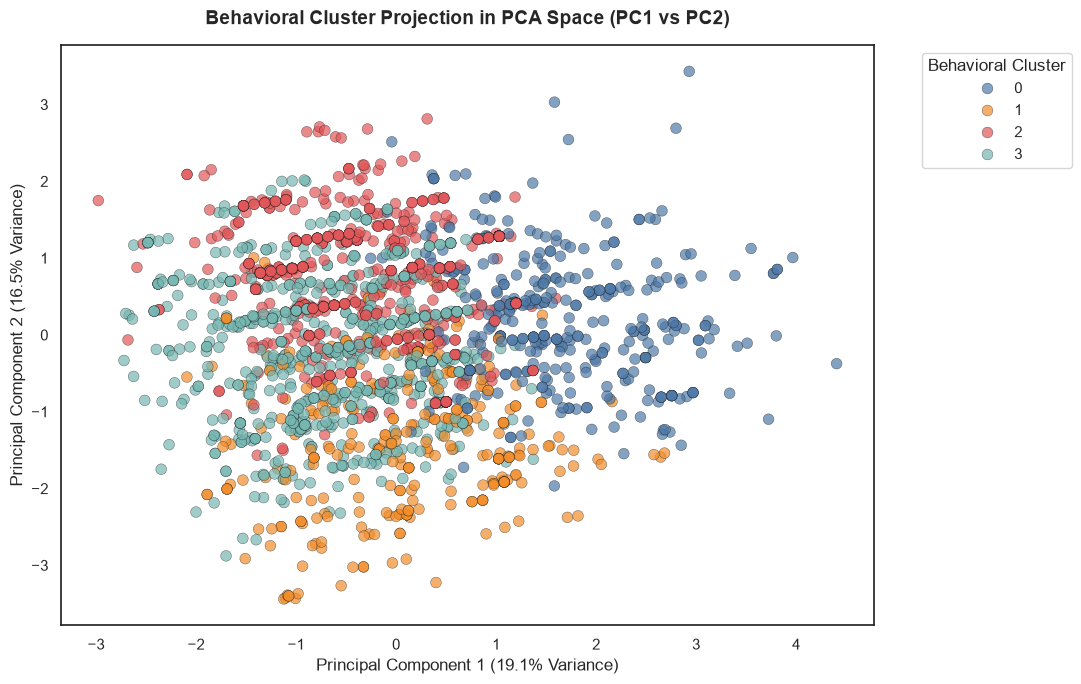

In [4]:
plt.figure(figsize=(11, 7))

# Plot Clusters
palette = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    data=df_pca, 
    palette=palette, 
    alpha=0.7, 
    s=60, 
    edgecolor='k', 
    linewidth=0.3
)

plt.title('Behavioral Cluster Projection in PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Principal Component 1 ({var_pc1:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.1f}% Variance)', fontsize=12)
plt.legend(title='Behavioral Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../visuals/pca_cluster_projection_2d.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.1 PCA Projection Diagnosis & Cluster Interpretation

While the scatterplot shows noticeable overlap among clusters near the center, this is a natural consequence of reducing 13 dimensions down to 2:

* **Low Variance Retention:** $PC_1$ ($19.1\%$) and $PC_2$ ($16.5\%$) retain a combined **$35.6\%$ of the total variance**, meaning over $64\%$ of the high-dimensional information is not visible in this 2D plane.
* **Directional Trends:** Despite the overlap, clear spatial groupings exist:
  * **Cluster 1 (Orange):** Drives the right side of the plot ($PC_1 > 0$).
  * **Cluster 0 (Blue):** Expands toward the bottom ($PC_2 < 0$).
  * **Cluster 3 (Green) & Cluster 2 (Red):** Occupy the upper-left area.
* **Conclusion:** The clusters are well-separated in the full 13D space (as proven by isolating severe obesity cases in Notebook 06), even if 2D PCA forces them to visually overlap.

## 3. Feature Loadings (Understanding PC Axes)

To understand what $PC_1$ and $PC_2$ actually represent, we evaluate the feature loadings matrix, which reveals how strongly each original habit drives the main axes of variance.

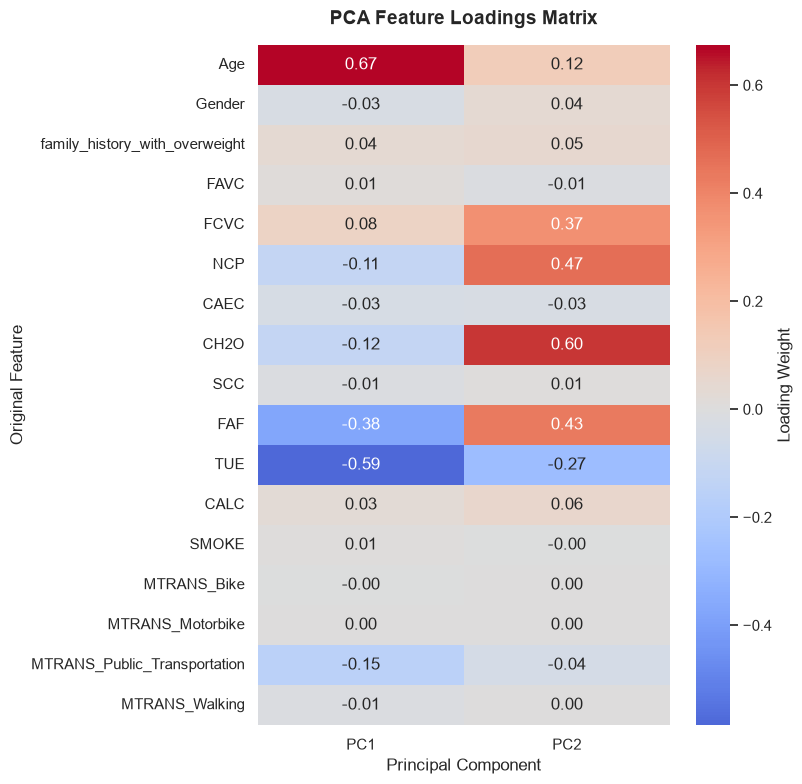

In [6]:
# Create loadings dataframe
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=X_features.columns
)

plt.figure(figsize=(8, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={'label': 'Loading Weight'})
plt.title('PCA Feature Loadings Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Original Feature', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/pca_feature_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.1 Interpretation of Principal Component Drivers

Analyzing the loading weights reveals the core behavioral drivers for each axis:

#### **Principal Component 1 ($PC_1$ - Horizontal Axis): "Age vs. Screen Time"**
* **Primary Positive Driver:** `Age` (**$+0.67$**) — Represents older individuals.
* **Primary Negative Drivers:** `TUE` (**$-0.59$**, Screen Time) and `FAF` (**$-0.38$**, Physical Activity) — Represent younger individuals spending more time on screens.
* **Takeaway:** $PC_1$ naturally separates the population by **age and digital lifestyle** (Adults on the right vs. Younger screen-users on the left).

#### **Principal Component 2 ($PC_2$ - Vertical Axis): "Dietary Volume & Hydration"**
* **Primary Positive Drivers:** `CH2O` (**$+0.60$**, Water Intake), `NCP` (**$+0.47$**, Meals per Day), `FAF` (**$+0.43$**, Physical Activity), and `FCVC` (**$+0.37$**, Vegetable Consumption).
* **Takeaway:** $PC_2$ measures **overall lifestyle intake and routine intensity** (High intake/activity at the top vs. Lower intake at the bottom).

---
## Final Conclusions & Unsupervised Pipeline Summary

1. **Successful Unsupervised Segmentation:** Using distance-based K-Means on behavioral features, we identified 4 naturally occurring archetypes in the population.
2. **Leakage-Free Validation:** By isolating physical metrics ($BMI$, $NObeyesdad$), we proved that behavioral habits naturally map into health outcome severities (e.g., Cluster 3 isolated severe obesity cases purely through dietary/activity patterns).
3. **Actionable Business Insights:**
   * **Cluster 0 (Young, Tech-Heavy):** Targets for digital activity & healthy dietary intervention.
   * **Cluster 1 (Older, High BMI):** Targets for chronic metabolic risk management.
   * **Cluster 2 (Meal Skippers):** Targets for dietary regularity education.
   * **Cluster 3 (High Volume / Severe Risk):** Candidates for intensive metabolic and lifestyle rehabilitation programs.